# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

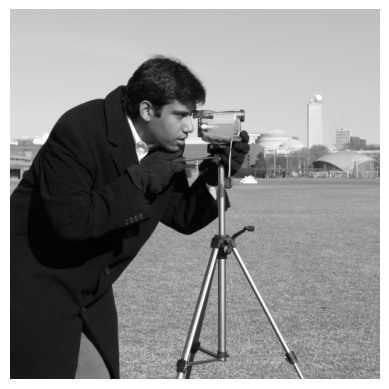

In [3]:
# ── Load image ────────────────────────────────────

original_image = data.camera()

plt.imshow(original_image, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [4]:
# Get the size of the image
img = Image.fromarray(original_image)

width, height = img.size

# Scaling factors
scale_x = 2
scale_y = 2

print("Original size:", width, "x", height)

Original size: 512 x 512


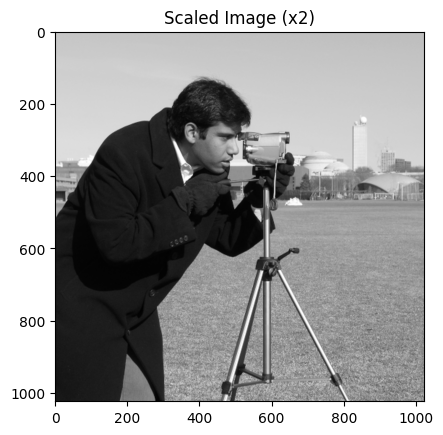

In [5]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_size = (width * scale_x, height * scale_y)

scaled_image = img.resize(new_size, Image.Resampling.LANCZOS)

plt.imshow(scaled_image, cmap = "gray")
plt.title("Scaled Image (x2)")
plt.show()


In [6]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save('task1_1_scaled.jpg')

print("Orignal size:", img.size)
print("Scaled size:", scaled_image.size)


Orignal size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
cx = 2
cy = 1

width, height = img.size

new_width = width * cx

new_height = height * cy

print("New dimentions:", new_width, "x", new_height)

New dimentions: 1024 x 512


In [8]:
nonuniform_size = (new_width, new_height)

nonuniform_image = img.resize(nonuniform_size, Image.Resampling.LANCZOS)

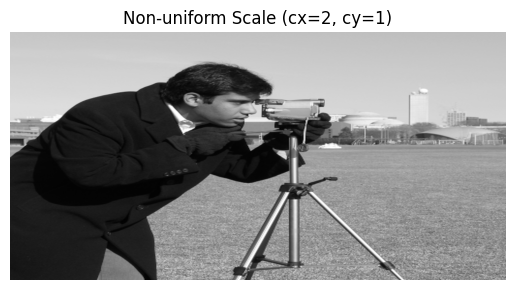

In [9]:
plt.imshow(nonuniform_image, cmap="gray")
plt.title("Non-uniform Scale (cx=2, cy=1)")
plt.axis("off")
plt.show()

In [10]:
nonuniform_image.save("task1_1_nonuniform.jpg")

print("Original size:", img.size)
print("Non-uniform size:", nonuniform_image.size)

Original size: (512, 512)
Non-uniform size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [14]:
from PIL.Image import Resampling

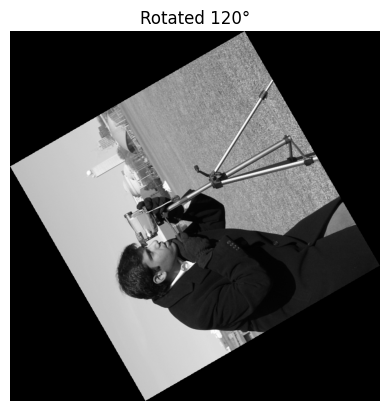

Original size: (512, 512)
Rotated size: (700, 700)


In [15]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_image = img.rotate(120, resample = Resampling.BICUBIC, expand = True)

rotated_image.save("task1_2_rotated.jpg")

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 120°")
plt.axis("off")
plt.show()

print("Original size:", img.size)
print("Rotated size:", rotated_image.size)


### 3. Shear

In [17]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Original size:", width, "x", height)

Original size: 512 x 512


In [18]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5

new_width = width + int(abs(shx) * height)
new_height = height

shear_matrix = (
    1, -shx, 0,
    0,  1,   0
)

print("New canvas size:", new_width, "x", new_height)


New canvas size: 768 x 512


X_new​ = x   + (shx *  y )

      = 512 + (0.5 * 512)

      = 768

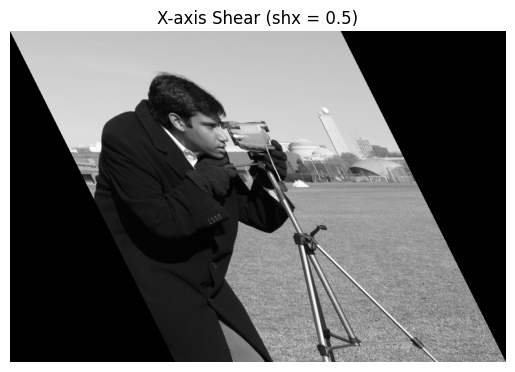

In [19]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_image = img.transform(
    (new_width, new_height), # sets the output canvas size.
    Image.Transform.AFFINE, # selects an affine transformation
    shear_matrix, # supplies the transformation values.
    resample=Image.Resampling.BICUBIC, # produces smoother pixels
    fillcolor=0 # makes empty regions black
)

plt.imshow(sheared_image, cmap="gray")
plt.title("X-axis Shear (shx = 0.5)")
plt.axis("off")
plt.show()

In [20]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_image.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_image.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

### Compare different X-axis shear factors

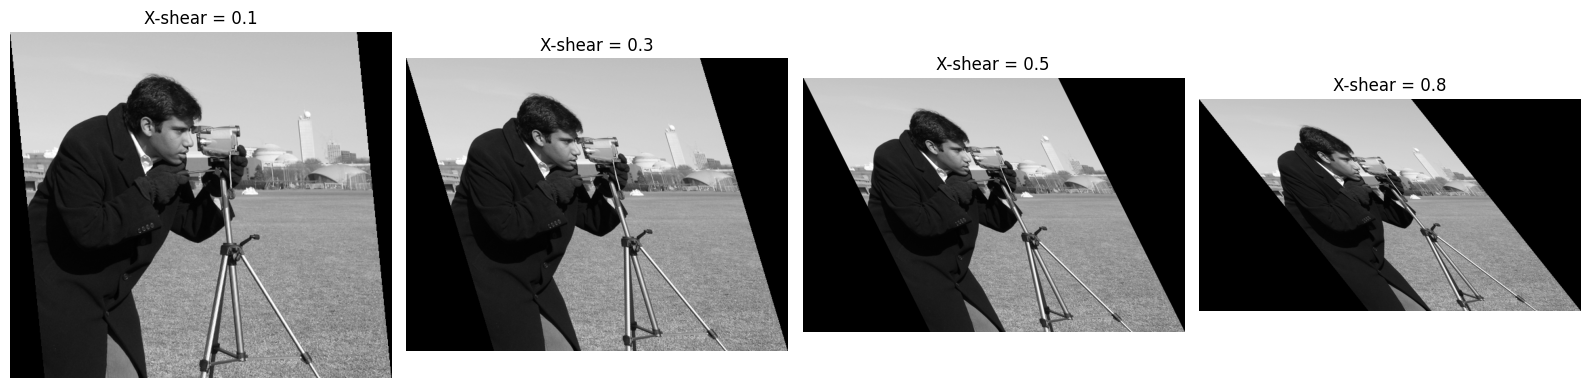

In [30]:
import math

shear_factors = [0.1, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(
    1,
    len(shear_factors),
    figsize=(4 * len(shear_factors), 4)
)

for ax, shx in zip(axes, shear_factors):

    # Update the canvas width for each shear factor
    new_width = width + math.ceil(abs(shx) * height)

    # Inverse X-shear matrix
    x_shear_matrix = (
        1, -shx, 0,
        0,  1,   0
    )

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        x_shear_matrix,
        resample=Image.Resampling.BICUBIC,
        fillcolor=0
    )

    ax.imshow(result, cmap="gray")
    ax.set_title(f"X-shear = {shx}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("task1_3_x_shear_comparison.jpg")
plt.show()

### Switch to a Y-axis shear

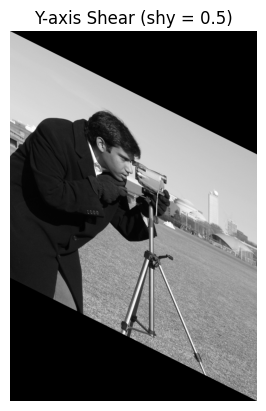

Original size: (512, 512)
Y-shear size: (512, 768)


In [31]:
shy = 0.5

# Height increases for a Y-axis shear
new_height = height + math.ceil(abs(shy) * width)

# Inverse Y-shear matrix
y_shear_matrix = (
    1,    0, 0,
    -shy, 1, 0
)

y_sheared_image = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    y_shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

plt.imshow(y_sheared_image, cmap="gray")
plt.title("Y-axis Shear (shy = 0.5)")
plt.axis("off")
plt.show()

y_sheared_image.save("task1_3_y_sheared.jpg")

print("Original size:", img.size)
print("Y-shear size:", y_sheared_image.size)

### Combine X and Y shear

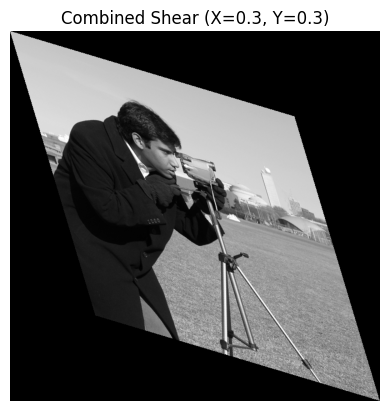

In [32]:
shx = 0.3
shy = 0.3

combined_width = width + math.ceil(abs(shx) * height)
combined_height = height + math.ceil(abs(shy) * width)

# Calculate the inverse of the combined shear matrix
determinant = 1 - (shx * shy)

combined_matrix = (
    1 / determinant,
    -shx / determinant,
    0,
    -shy / determinant,
    1 / determinant,
    0
)

combined_shear = img.transform(
    (combined_width, combined_height),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

plt.imshow(combined_shear, cmap="gray")
plt.title(f"Combined Shear (X={shx}, Y={shy})")
plt.axis("off")
plt.show()

combined_shear.save("task1_3_combined_shear.jpg")

# Intensity Transformations
Negative · Log · Power Law (Gamma)

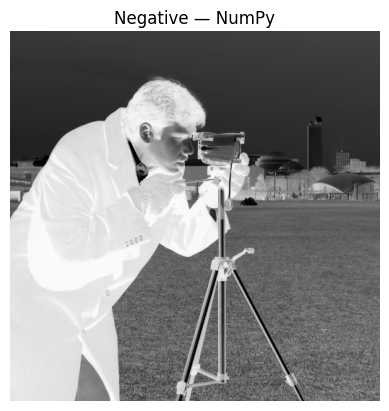

In [21]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)

# Apply the negative transformation
negative_array = 255 - img_array

# Convert the result back to a PIL image
negative_numpy = Image.fromarray(negative_array)

# Display the result
plt.imshow(negative_numpy, cmap="gray")
plt.title("Negative — NumPy")
plt.axis("off")
plt.show()

# Save the result
negative_numpy.save("task2_1_negative_numpy.jpg")


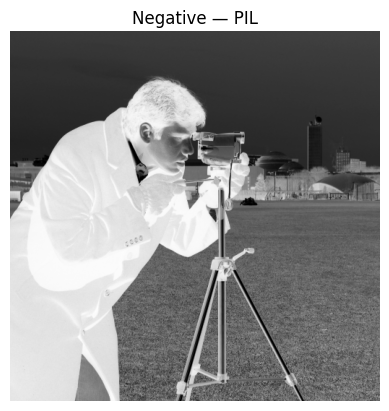

In [22]:
# Method 2: PIL's ImageOps

from PIL import ImageOps

negative_pil = ImageOps.invert(img)

plt.imshow(negative_pil, cmap="gray")
plt.title("Negative — PIL")
plt.axis("off")
plt.show()

negative_pil.save("task2_1_negative_pil.jpg")

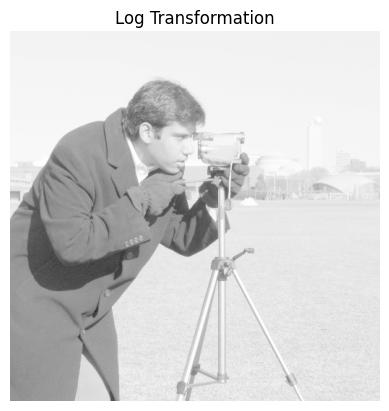

In [23]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)


# Apply the log transformation to each pixel
# Convert to float before applying the logarithm
img_float = np.array(img, dtype=np.float32)

# Calculate the normalization constant
c = 255 / np.log1p(255)

# Apply the log transformation
log_array = c * np.log1p(img_float)

# Ensure valid 8-bit pixel values
log_array = np.clip(log_array, 0, 255).astype(np.uint8)

# Convert back to a PIL image
log_image = Image.fromarray(log_array)

plt.imshow(log_image, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()

log_image.save("task2_2_log.jpg")

Log transformation generally makes dark details more visible because it expands low-intensity values while compressing high-intensity values

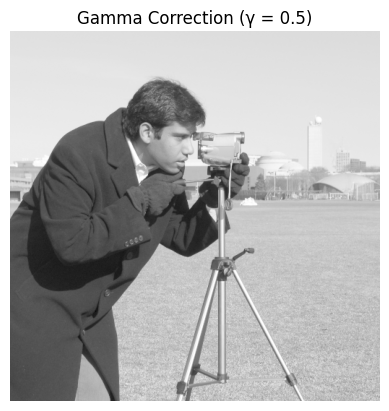

In [24]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

# Normalize pixels to the range 0–1
normalized_array = np.array(img, dtype=np.float32) / 255.0

# Apply gamma correction
gamma_array = 255 * (normalized_array ** gamma)

# Convert to uint8
gamma_array = np.clip(gamma_array, 0, 255).astype(np.uint8)

# Convert back to a PIL image
gamma_image = Image.fromarray(gamma_array)

plt.imshow(gamma_image, cmap="gray")
plt.title(f"Gamma Correction (γ = {gamma})")
plt.axis("off")
plt.show()

gamma_image.save("task2_3_gamma.jpg")

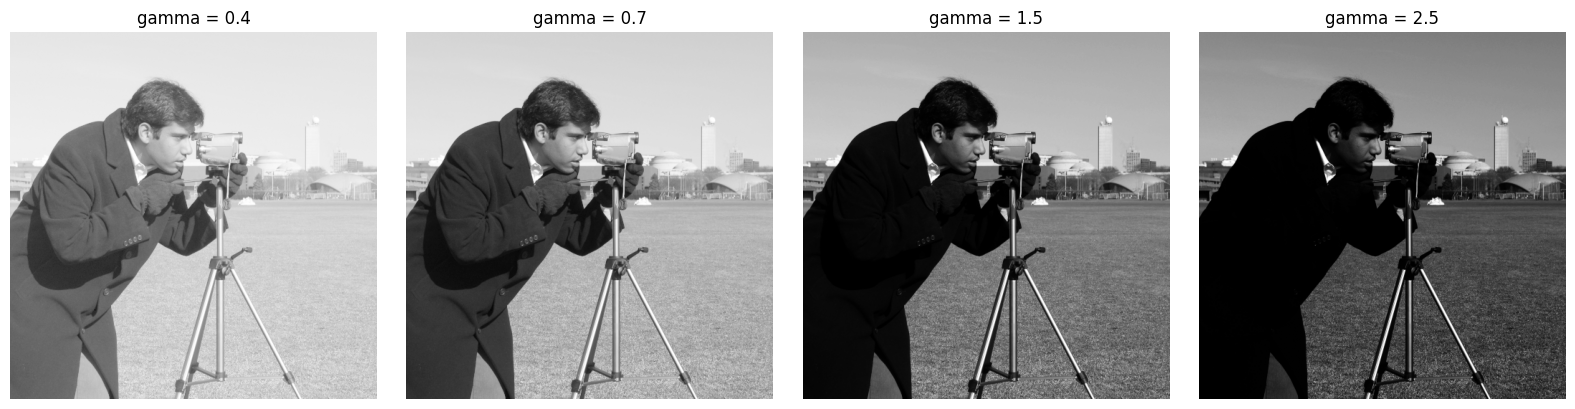

In [29]:
gammas = [0.4, 0.7, 1.5, 2.5]
normalized_array = np.array(img, dtype=np.float32) / 255.0

fig, axes = plt.subplots(1, len(gammas), figsize=(4 * len(gammas), 4))
for ax, g in zip(axes, gammas):
    result = np.clip(np.power(normalized_array, g) * 255.0, 0, 255).astype(np.uint8)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"gamma = {g}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("task2_3_gamma_compaing.jpg")
plt.show()